### Step 1: Import Libraries

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn import metrics

In [4]:
from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor

In [53]:
from feature_engine.selection import SmartCorrelatedSelection
from feature_engine.outliers import OutlierTrimmer

### Step 2: Load Data

In [6]:
df = pd.read_csv('./data/tips.csv')

In [7]:
df.shape

(244, 7)

In [8]:
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


### Step 3: Exploaring Data

#### Basic Info

In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
total_bill,244.0,19.785943,8.902412,3.07,13.3475,17.795,24.1275,50.81
tip,244.0,2.998279,1.383638,1.00,2.0000,2.900,3.5625,10.00
size,244.0,2.569672,0.951100,1.00,2.0000,2.000,3.0000,6.00


In [10]:
feature_info = pd.DataFrame(
    {
        'null': df.isnull().sum(),
        'null(%)': round(100 * df.isnull().sum() / len(df), 3),
        'unique': df.nunique(),
        'type': df.dtypes
    }
)

In [11]:
feature_info

,null,null(%),unique,type
total_bill,0,0.0,229,float64
tip,0,0.0,123,float64
sex,0,0.0,2,object
smoker,0,0.0,2,object
day,0,0.0,4,object
time,0,0.0,2,object
size,0,0.0,6,int64


#### Target Distribution

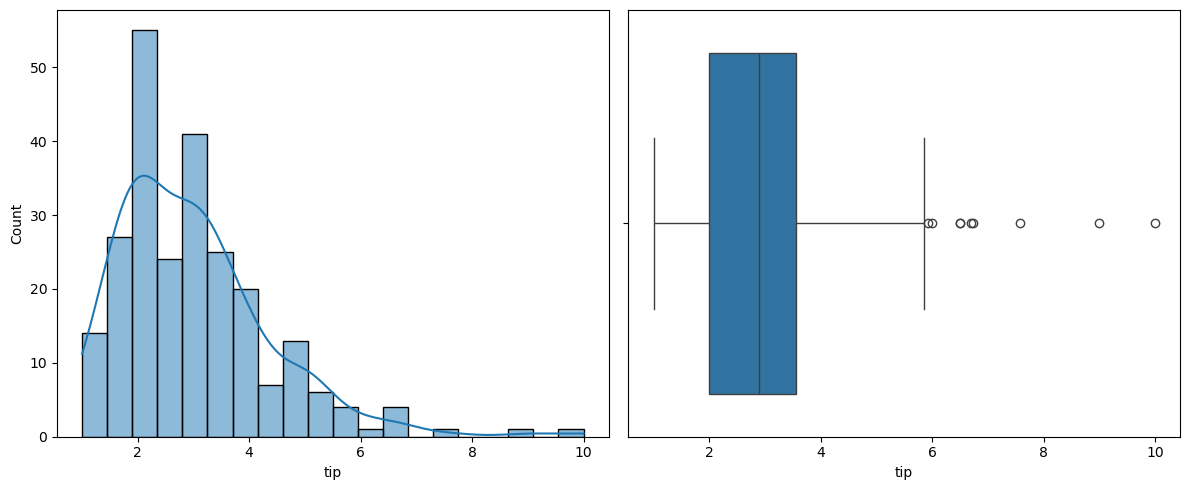

In [12]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(x='tip', data=df, bins=20, kde=True)
plt.subplot(1, 2, 2)
sns.boxplot(x='tip', data=df, orient='h')
plt.tight_layout()

#### Object Distribution

In [20]:
discrete_cols = df.select_dtypes([object, int]).columns.to_list()

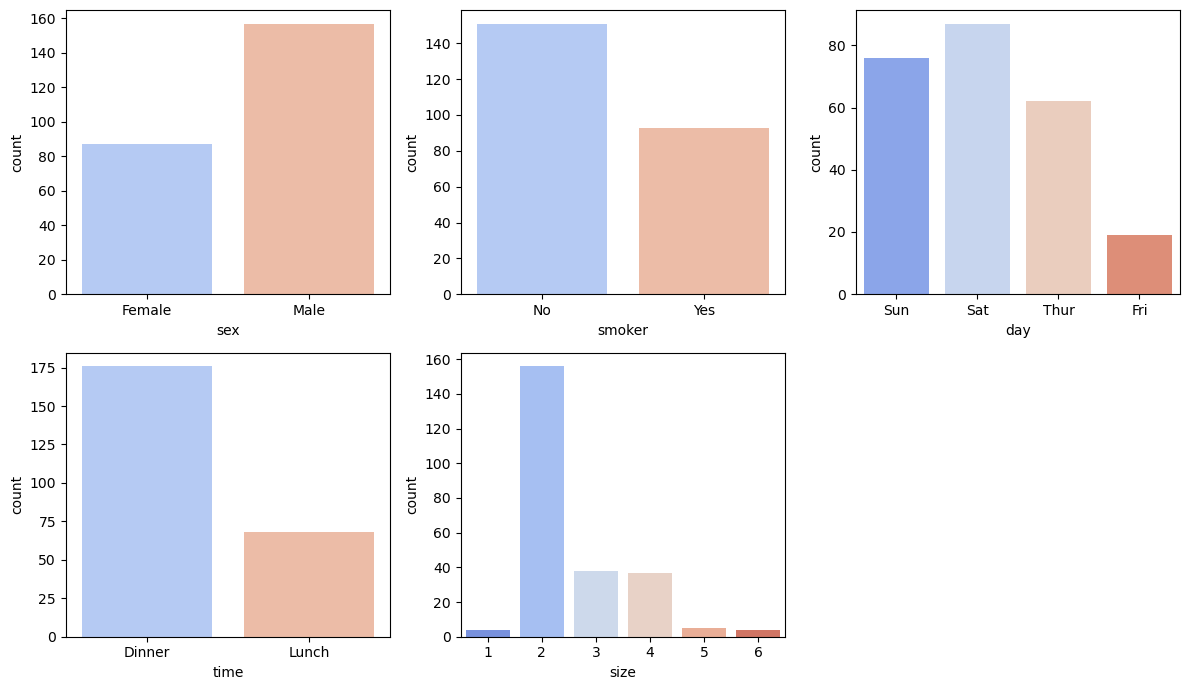

In [25]:
plt.figure(figsize=(12, 7))
for i, col in enumerate(discrete_cols):
    plt.subplot(2, 3, i+1)
    sns.countplot(x=col, data=df, palette='coolwarm')
plt.tight_layout()

#### Float Distribution

In [15]:
float_cols = df.select_dtypes(float).columns.to_list()

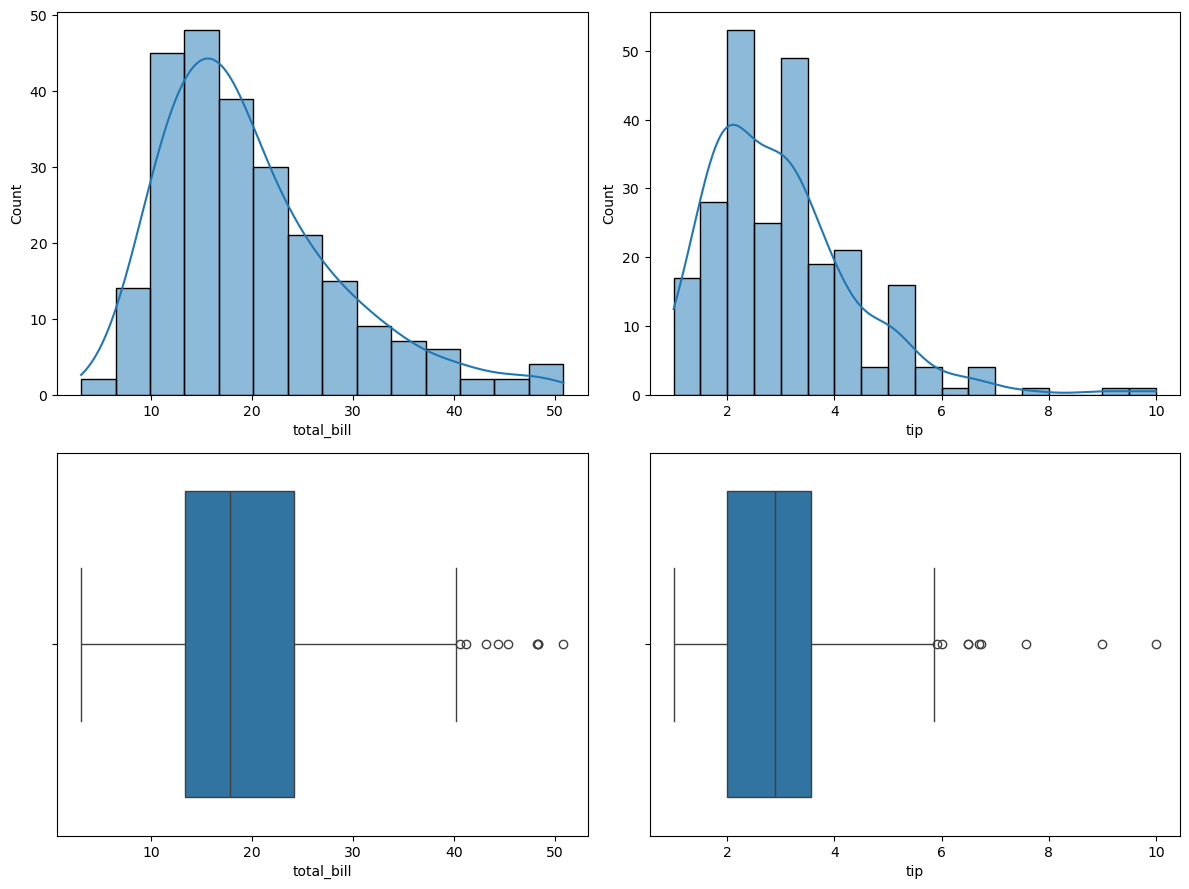

In [17]:
plt.figure(figsize=(12, 9))
for i, col in enumerate(float_cols):
    plt.subplot(2, 2, i+1)
    sns.histplot(x=col, data=df, kde=True)
    plt.subplot(2, 2, 3+i)
    sns.boxplot(x=col, data=df, orient='h')
plt.tight_layout()

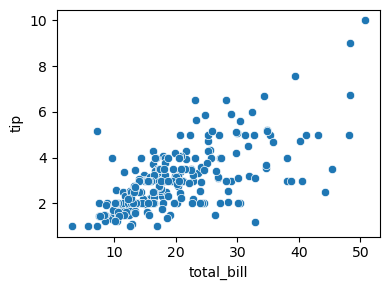

In [31]:
plt.figure(figsize=(4, 3))
sns.scatterplot(x='total_bill', y='tip', data=df)
plt.tight_layout()

In [42]:
temp = df.melt(
    id_vars='size',
    value_vars=['total_bill', 'tip'],
    var_name='metric',
    value_name='value'
)

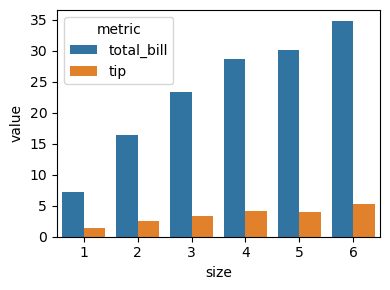

In [43]:
plt.figure(figsize=(4, 3))
sns.barplot(x='size', y='value', hue='metric', data=temp, errorbar=None)
plt.tight_layout()

In [44]:
df.groupby('size').mean(numeric_only=True)

,total_bill,tip
size,,
1,7.242500,1.437500
2,16.448013,2.582308
3,23.277632,3.393158
4,28.613514,4.135405
5,30.068000,4.028000
6,34.830000,5.225000


In [45]:
df.groupby('time').mean(numeric_only=True)

,total_bill,tip,size
time,,,
Dinner,20.797159,3.102670,2.630682
Lunch,17.168676,2.728088,2.411765


In [46]:
df.groupby('day').mean(numeric_only=True)

,total_bill,tip,size
day,,,
Fri,17.151579,2.734737,2.105263
Sat,20.441379,2.993103,2.517241
Sun,21.410000,3.255132,2.842105
Thur,17.682742,2.771452,2.451613


### Step 4: Feature Engineering

#### Handling Outlier

In [67]:
trimmer = OutlierTrimmer(
    capping_method='iqr',
    tail='both',
    fold=2,
    variables=['total_bill', 'tip']
)

In [71]:
df = trimmer.fit_transform(df)

#### Label Encode

In [72]:
obj_cols = df.select_dtypes(object).columns.to_list()

In [74]:
for col in obj_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

#### Heat Map

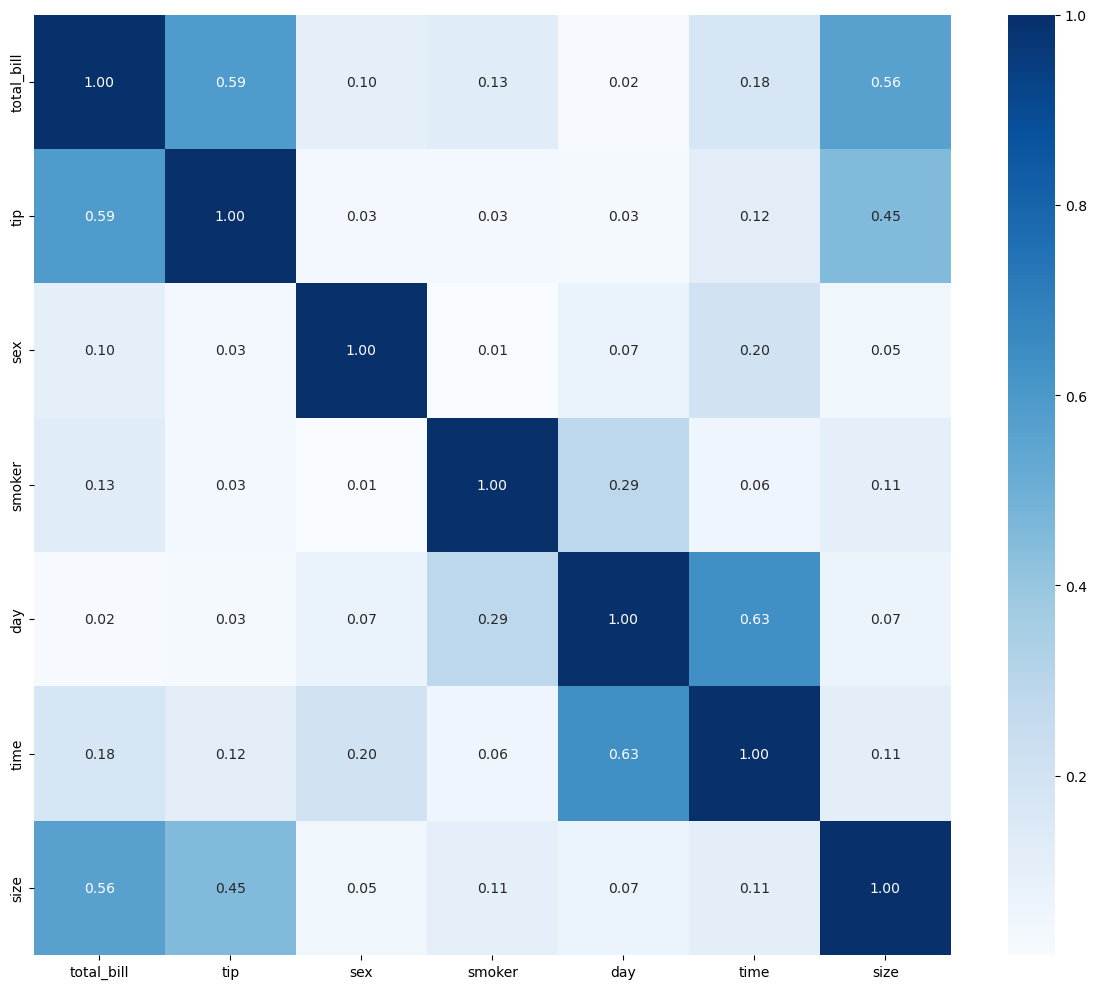

In [75]:
plt.figure(figsize=(12, 10))
sns.heatmap(
    df.corr().abs(),
    fmt='.2f',
    annot=True,
    cmap=plt.cm.Blues
)
plt.tight_layout()

### Step 5: Preparing Data

#### Select Features

In [76]:
features = df.drop('tip', axis=1)
target = df['tip']

In [79]:
raw_features = features.columns.to_list()

In [78]:
selector = SmartCorrelatedSelection(threshold=0.8, selection_method='corr_with_target')

In [80]:
features = selector.fit_transform(features, target)

In [81]:
deal_features = features.columns.to_list()

In [82]:
delete_features = list(set(raw_features) - set(deal_features))

In [83]:
print('raw features:', raw_features)
print('deal features:', deal_features)
print('delete features:', delete_features)

raw features: ['total_bill', 'sex', 'smoker', 'day', 'time', 'size']
deal features: ['total_bill', 'sex', 'smoker', 'day', 'time', 'size']
delete features: []


#### Split Data

In [84]:
X_train, X_test, y_train, y_test = train_test_split(
    features,
    target,
    test_size=0.2,
    random_state=42
)

#### Normalization

In [85]:
scaler = StandardScaler()

In [86]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### Step 6: Model Development

In [90]:
models = [
    LinearRegression(),
    XGBRegressor(),
    RandomForestRegressor(),
    AdaBoostRegressor()
]

In [91]:
for model in models:
    print('-'*20, f'model:{model.__class__.__name__}', '-'*20)
    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring='neg_mean_absolute_error',
        n_jobs=-1,
        error_score='raise'
    )
    print('training mae scores:', [round(-1 * x, 3) for x in scores])
    print('training mae score:', round(-1 * scores.mean(), 3))
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print('testing mae score:', round(metrics.mean_absolute_error(y_test, y_pred), 3))

-------------------- model:LinearRegression --------------------
training mae scores: [0.704, 0.726, 0.743, 0.719, 0.713]
training mae score: 0.721
testing mae score: 0.759
-------------------- model:XGBRegressor --------------------
training mae scores: [0.812, 0.737, 1.018, 0.849, 0.771]
training mae score: 0.837
testing mae score: 0.755
-------------------- model:RandomForestRegressor --------------------
training mae scores: [0.761, 0.637, 0.872, 0.799, 0.61]
training mae score: 0.736
testing mae score: 0.733
-------------------- model:AdaBoostRegressor --------------------
training mae scores: [0.741, 0.681, 0.862, 0.737, 0.628]
training mae score: 0.73
testing mae score: 0.762
